<h1><b>Importing Libraries

In [1]:
! pip install -q tensorflow_hub

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Model
from PIL import Image
from transformers import pipeline
from tqdm import tqdm
import time
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import tensorflow_hub as hub
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import cohen_kappa_score

<h1><b>Selecting Samples Using Predefined Indices

In [4]:
import numpy as np
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()

subset_indices = np.load("subset_indices.npy")

x_train, y_train = x_train[subset_indices], y_train[subset_indices]

In [5]:
x_train.shape

(10000, 32, 32, 3)

<h1><b>Orientation of Images in 2D Space (t-SNE Visualisation)

In [ ]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_embedded = tsne.fit_transform(x_train_flat)

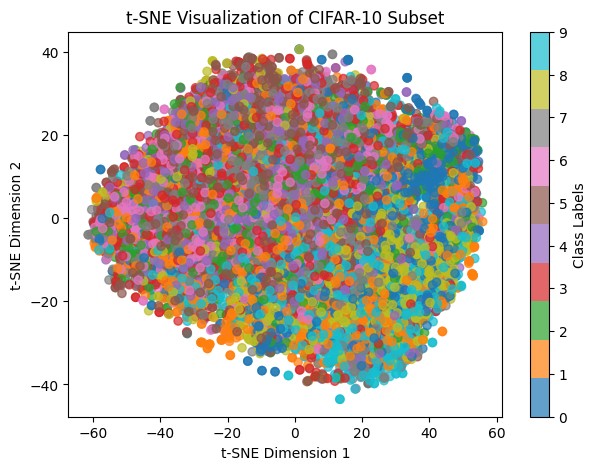

In [9]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=y_train, cmap="tab10", alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.title("t-SNE Visualization of CIFAR-10 Subset")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

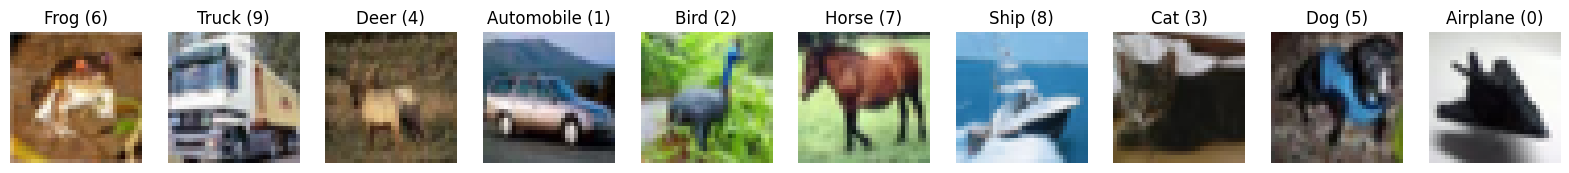

In [7]:
class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer",
               "Dog", "Frog", "Horse", "Ship", "Truck"]

unique_classes = np.unique(y_train)
selected_images = {}

for i, label in enumerate(y_train):
    if label not in selected_images:
        selected_images[label] = x_train[i]
    if len(selected_images) == len(unique_classes):
        break

fig, axes = plt.subplots(1, len(unique_classes), figsize=(20, 10))

for ax, (label, img) in zip(axes, selected_images.items()):
    ax.imshow(img)
    ax.set_title(f"{class_names[label]} ({label})", fontsize=12)
    ax.axis("off")

plt.show()

<h1><b>Resizing Image

In [ ]:
x_train = x_train.astype('float32')
x_train = tf.image.resize(x_train, (32, 32))

In [ ]:
print(f"Train shape: {x_train.shape}")

Train shape: (10000, 32, 32, 3)


<h1><b>MobileNet Model for Visual Features

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

<ipython-input-7-375b64fe08b7>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def extract_visual_features(images, preprocess_fn):
    images = preprocess_fn(images)
    features = feature_extractor.predict(images, batch_size=32, verbose=1)
    return features

In [ ]:
visual_features_train = extract_visual_features(x_train, mobilenet_preprocess)
visual_features_test = extract_visual_features(x_test, mobilenet_preprocess)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


<h1><b> Image Captioning Model

In [ ]:
image_to_text = pipeline("image-to-text", model="nlpconnect/vit-gpt2-image-captioning")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_rang

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


<h1><b> Generating of Captions using VIT-GPT2

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print("Available GPUs:", gpus)

strategy = tf.distribute.MirroredStrategy(devices=["/gpu:0", "/gpu:1"])

def generate_captions_batch(images):
    images = images.numpy()
    pil_images = [Image.fromarray(image.astype(np.uint8)) for image in images]

    captions = []
    for idx, image in enumerate(tqdm(pil_images, desc="Generating Captions")):
        caption = image_to_text(image)
        print(f"Generated Caption for Image {idx + 1}: {caption}")
        captions.append(caption)

    return captions


with strategy.scope():
    captions_train = generate_captions_batch(x_train)

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Generating Captions:   0%|          | 0/10000 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.
Generating Captions:   0%|          | 2/10000 [00:01<1:23:42,  1.99it/s]

Generated Caption for Image 1: [{'generated_text': 'a small bird is standing on a dirt ground '}]
Generated Caption for Image 2: [{'generated_text': 'a large truck is driving down the road '}]


Generating Captions:   0%|          | 4/10000 [00:01<45:00,  3.70it/s]

Generated Caption for Image 3: [{'generated_text': 'a dump truck is parked on a dirt road '}]
Generated Caption for Image 4: [{'generated_text': 'a small sheep standing in a field '}]


...

Generated Caption for Image 9995: [{'generated_text': 'a white dog standing next to a white dog '}]
Generated Caption for Image 9996: [{'generated_text': 'a woman is standing next to a dog '}]


Generating Captions: 100%|█████████▉| 9998/10000 [36:05<00:00,  4.96it/s]

Generated Caption for Image 9997: [{'generated_text': 'two white dogs sitting on a table '}]
Generated Caption for Image 9998: [{'generated_text': 'a small dog sitting on a blue blanket '}]


Generating Captions: 100%|██████████| 10000/10000 [36:06<00:00,  4.62it/s]

Generated Caption for Image 9999: [{'generated_text': 'a dog is looking at the camera while standing on the floor '}]
Generated Caption for Image 10000: [{'generated_text': 'a dog with a leash on a sidewalk '}]


<h1><b> KMeans Clustering of Visual Features (Total 10 Classes)

In [ ]:
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
visual_features_train = visual_features_train.reshape(visual_features_train.shape[0], -1)
kmeans_labels_visual = kmeans.fit_predict(visual_features_train)

<h1><b> tSNE Visualisation of Visual Feature Clusters by KMeans

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


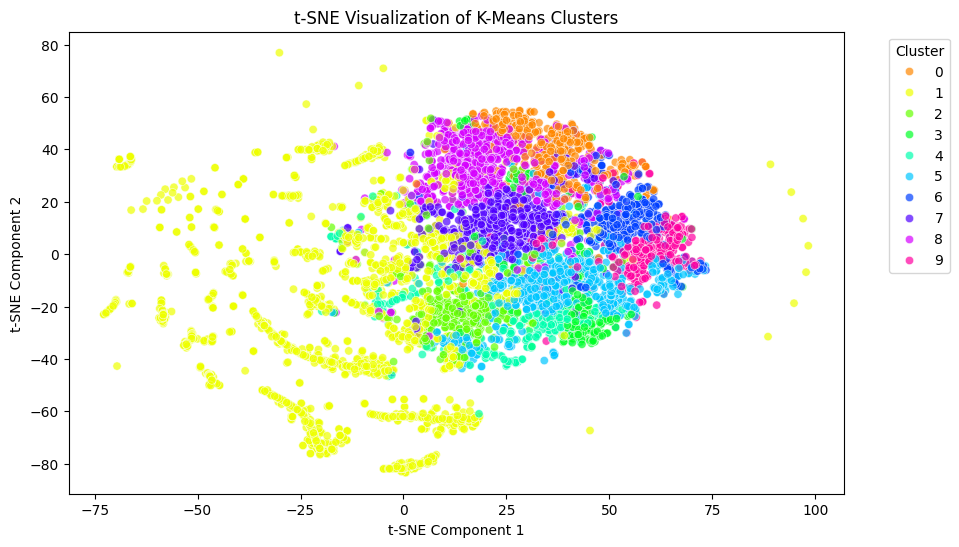

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
visual_features_2d = tsne.fit_transform(visual_features_train)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=visual_features_2d[:, 0],
    y=visual_features_2d[:, 1],
    hue=kmeans_labels_visual,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of K-Means Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


<h1><b> Gaussian Mixture Model for clustering of visual features

In [ ]:
gmm = GaussianMixture(n_components=num_clusters, random_state=42)
gmm_labels_visual = gmm.fit_predict(visual_features_train)

<h1><b>tSNE Visualisation of Visual Feature Clusters by Gaussian Mixture Model

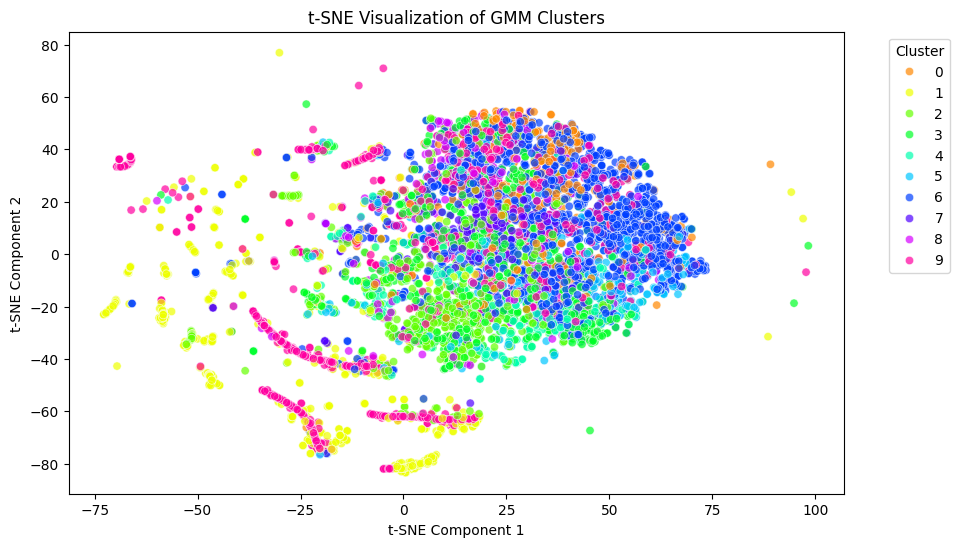

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=visual_features_2d[:, 0],
    y=visual_features_2d[:, 1],
    hue=gmm_labels_visual,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of GMM Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The `assign_cluster_labels` function maps cluster labels to the most common true class labels in an unsupervised clustering setup. It iterates through each cluster, finds the data points assigned to that cluster, determines the most frequently occurring true label among them, and assigns that label to the cluster. Finally, it replaces each cluster label with its corresponding mapped class label, returning an array of predicted labels for all samples. This is useful for interpreting clustering results in relation to ground truth labels.

In [ ]:
def assign_cluster_labels(cluster_labels, true_labels):
    label_map = {}
    for cluster in range(num_clusters):
        indices = np.where(cluster_labels == cluster)[0]
        most_common_class = Counter(true_labels[indices]).most_common(1)[0][0]
        label_map[cluster] = most_common_class
    return np.array([label_map[label] for label in cluster_labels])

In [ ]:
kmeans_assigned_labels = assign_cluster_labels(kmeans_labels_visual, y_train)
gmm_assigned_labels = assign_cluster_labels(gmm_labels_visual, y_train)

<h1><b>Cohen-Kappa Score Calculation

In [ ]:
kmeans_kappa = cohen_kappa_score(y_train, kmeans_assigned_labels)
gmm_kappa = cohen_kappa_score(y_train, gmm_assigned_labels)

print(f"K-Means Cohen Kappa Score for visual features: {kmeans_kappa:.4f}")
print(f"GMM Cohen Kappa Score for visual features : {gmm_kappa:.4f}")

K-Means Cohen Kappa Score for visual features: 0.1051
GMM Cohen Kappa Score for visual features : 0.0906


<h1><b> Loading Embedding Generation Model

In [ ]:
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

In [ ]:
def get_text_embeddings(captions):
    texts = [item['generated_text'] for sublist in captions for item in sublist]
    return use_model(texts).numpy()


In [ ]:
text_embeddings = get_text_embeddings(captions_train)

<h1><b> KMeans Clustering for Textual Features

In [ ]:
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels_kmeans_textual = kmeans.fit_predict(text_embeddings)

<h1><b>t-SNE Visualisation of Textual Features(using KMeans Clustering)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


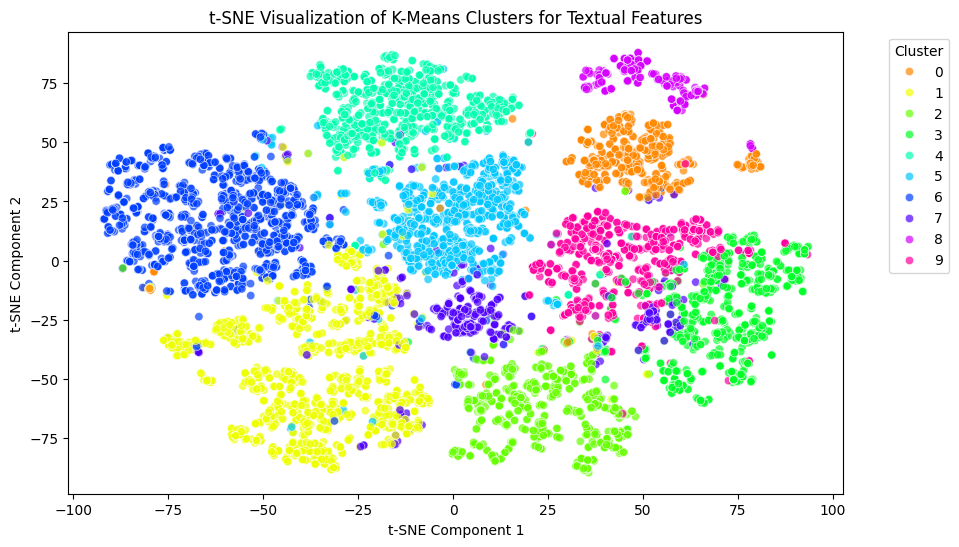

In [ ]:
textual_features_2d = tsne.fit_transform(text_embeddings)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=textual_features_2d[:, 0],
    y=textual_features_2d[:, 1],
    hue=cluster_labels_kmeans_textual,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of K-Means Clusters for Textual Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<h1><b> Gaussian Mixture Model for Textual Features

In [ ]:
gmm = GaussianMixture(n_components=num_clusters, random_state=42)
cluster_labels_gmm_textual = gmm.fit_predict(text_embeddings)

<h1><b> t-SNE Visualisation for Textual Features(clustered by Gaussian Mixture Model)

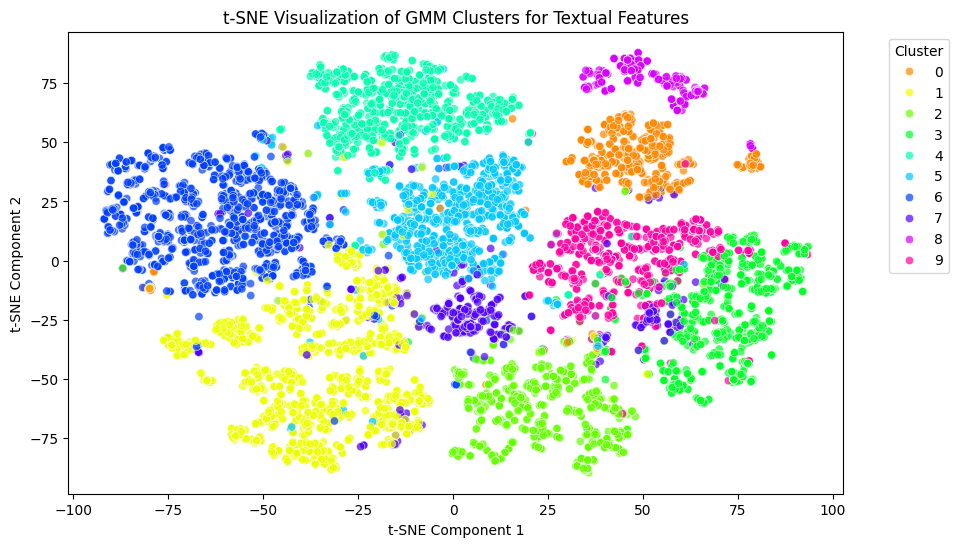

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=textual_features_2d[:, 0],
    y=textual_features_2d[:, 1],
    hue=cluster_labels_gmm_textual,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of GMM Clusters for Textual Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The `assign_majority_label` function assigns each cluster a label based on the most frequent true class within that cluster. It first identifies unique clusters, determines the indices of data points in each cluster, and finds the most common true label using the `Counter` class. It then maps each cluster to its majority class and replaces cluster labels with these mapped class labels, returning an array of assigned labels. This function helps interpret clustering results by aligning them with actual class distributions.

In [ ]:
def assign_majority_label(cluster_labels, y_true):
    cluster_to_label = {}
    for cluster in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster)[0]
        majority_class = Counter(y_true[indices].flatten()).most_common(1)[0][0]
        cluster_to_label[cluster] = majority_class

    assigned_labels = np.array([cluster_to_label[cluster] for cluster in cluster_labels])
    return assigned_labels

In [ ]:
y_pred_kmeans = assign_majority_label(cluster_labels_kmeans_textual, y_train)
y_pred_gmm = assign_majority_label(cluster_labels_gmm_textual, y_train)

<h1><b> Cohen-Kappa Score for Textual Features

In [ ]:
kappa_kmeans = cohen_kappa_score(y_train.flatten(), y_pred_kmeans)
kappa_gmm = cohen_kappa_score(y_train.flatten(), y_pred_gmm)

In [ ]:
print(f"Cohen Kappa for textual features using KMeans Clustering : {kappa_kmeans}")
print(f"Cohen Kappa for textual features using GMM Clustering : {kappa_gmm}")

Cohen Kappa for textual features using KMeans Clustering : 0.6872222222222222
Cohen Kappa for textual features using GMM Clustering : 0.6872222222222222


<h1><b> Fusion of Features : Concatenation of Visual and Textual Feature vectors

In [ ]:
fused_features_concatenated = np.concatenate([visual_features_train, text_embeddings], axis=1)

<h1><b> KMeans Clustering on Concatenated Features

In [ ]:
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
fused_cluster_labels_kmeans_concatenated = kmeans.fit_predict(fused_features_concatenated)

<h1><b> Cohen-Kappa Score calculation for Concatenated Features

In [ ]:
y_pred_kmeans_concatenated = assign_majority_label(fused_cluster_labels_kmeans_concatenated, y_train)
kappa_kmeans_concatenated = cohen_kappa_score(y_train.flatten(), y_pred_kmeans_concatenated)

print(f"Cohen Kappa for Concatenated Fusion of Features using KMeans Clustering : {kappa_kmeans_concatenated}")

Cohen Kappa for Concatenated Fusion of Features using KMeans Clustering : 0.18333333333333335


<h1><b> Fusion of Features : Weighted Average of Visual and Textual Features

We standardize visual and textual features using **StandardScaler** and apply **PCA** for dimensionality reduction, preserving key variance. The fused representation is obtained through a weighted combination, where visual features contribute **α = 0.1** and textual embeddings **0.9**, ensuring an optimized balance for downstream tasks.

In [ ]:
alpha = 0.1
scaler = StandardScaler()
visual_features_train_scaled = scaler.fit_transform(visual_features_train)
text_embeddings_scaled = scaler.fit_transform(text_embeddings)
n_components = min(visual_features_train_scaled.shape[1], text_embeddings_scaled.shape[1])
pca = PCA(n_components=n_components)
visual_features_pca = pca.fit_transform(visual_features_train_scaled)
text_embeddings_pca = pca.fit_transform(text_embeddings_scaled)
fused_features_train_weighted = alpha * visual_features_pca + (1 - alpha) * text_embeddings_pca

<h1><b> KMeans Clustering on Weighted Average of Features

In [ ]:
fused_cluster_labels_kmeans_weighted = kmeans.fit_predict(fused_features_train_weighted)

<h1><b> Cohen-Kappa Score calculation for Weighted Fusion of Features using KMeans Clustering

In [ ]:
y_pred_kmeans_weighted = assign_majority_label(fused_cluster_labels_kmeans_weighted, y_train)
kappa_kmeans_weighted = cohen_kappa_score(y_train.flatten(), y_pred_kmeans_weighted)

print(f"Cohen Kappa for Weighted Fusion of Features using KMeans Clustering : {kappa_kmeans_weighted}")

Cohen Kappa for Weighted Fusion of Features using KMeans Clustering : 0.6655555555555555


<h1><b>t-SNE Visualisation of Concatenated Fusion of Features using KMeans Clustering

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


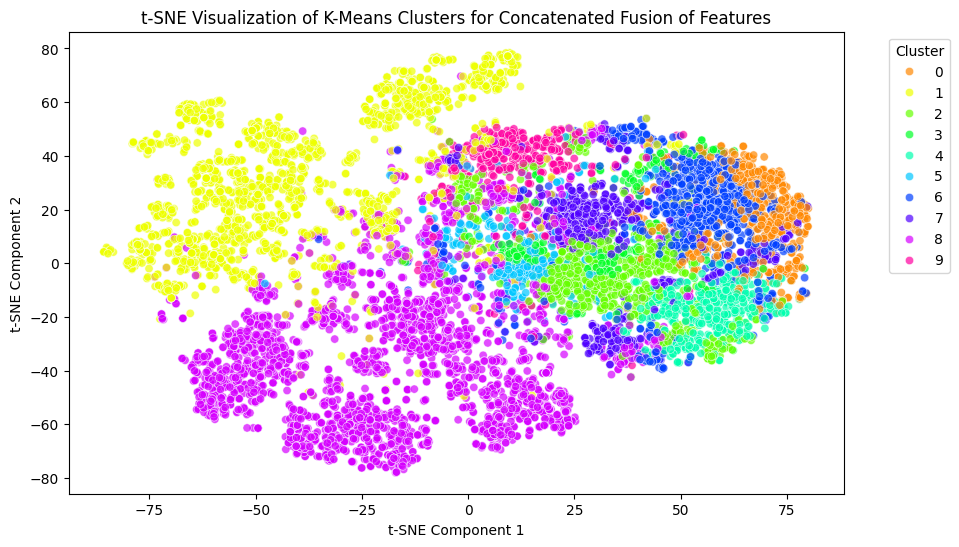

In [ ]:
concatenated_features_2d = tsne.fit_transform(fused_features_concatenated)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=concatenated_features_2d[:, 0],
    y=concatenated_features_2d[:, 1],
    hue=fused_cluster_labels_kmeans_concatenated,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of K-Means Clusters for Concatenated Fusion of Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<h1><b>t-SNE Visualisation of Weighted Fusion of Features using KMeans Clustering

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


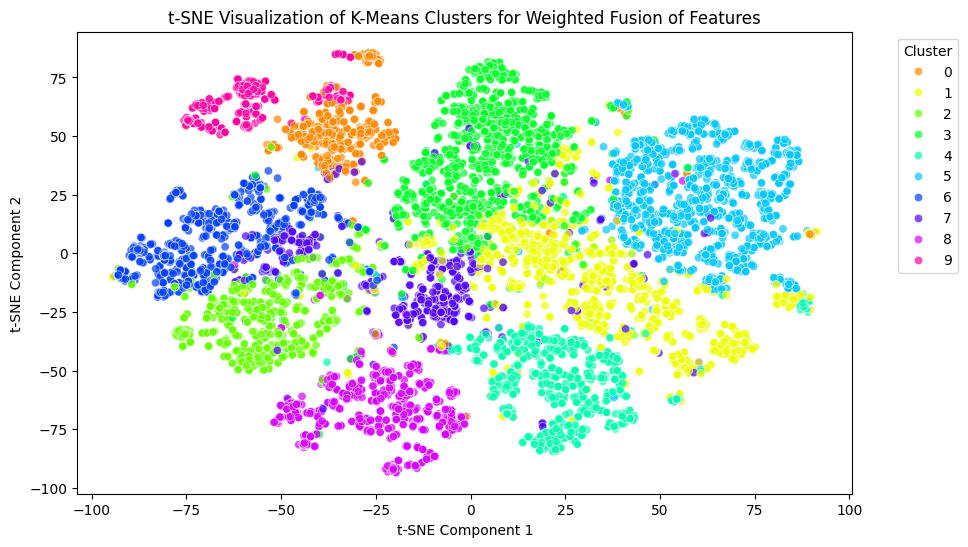

In [ ]:
weighted_features_2d = tsne.fit_transform(fused_features_train_weighted)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=weighted_features_2d[:, 0],
    y=weighted_features_2d[:, 1],
    hue=fused_cluster_labels_kmeans_weighted,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of K-Means Clusters for Weighted Fusion of Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
scaler = StandardScaler()
fused_features_train_scaled = scaler.fit_transform(fused_features_concatenated)

<h1><b> Gaussian Mixture Model for Concatenated Fusion of Features

In [ ]:
gmm = GaussianMixture(n_components=num_clusters, random_state=42)
fused_cluster_labels_gmm_concatenated = gmm.fit_predict(fused_features_train_scaled)

<h1><b>Cohen-Kappa Score for the Gaussian Mixture Model for Concatenated Fusion of Features

In [ ]:
y_pred_gmm_concatenated = assign_majority_label(fused_cluster_labels_gmm_concatenated, y_train)
kappa_gmm_concatenated = cohen_kappa_score(y_train.flatten(), y_pred_gmm_concatenated)

print(f"Cohen Kappa for Concatenated Fusion of Features using GMM Clustering : {kappa_gmm_concatenated}")

Cohen Kappa for Concatenated Fusion of Features using GMM Clustering : 0.5091111111111113


<h1><b>t-SNE Visualisation of Concatenated Fusion of Features using Gaussian Mixture Model

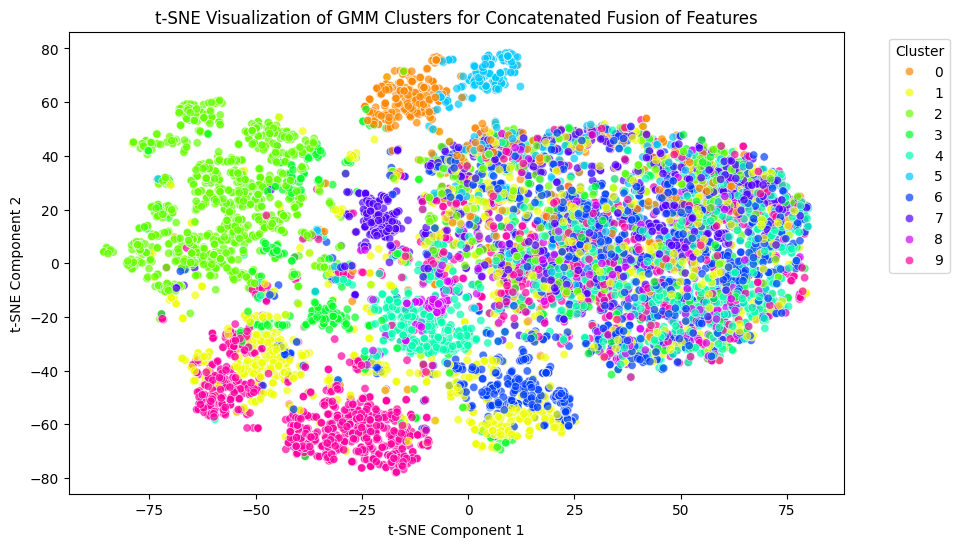

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=concatenated_features_2d[:, 0],
    y=concatenated_features_2d[:, 1],
    hue=fused_cluster_labels_gmm_concatenated,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of GMM Clusters for Concatenated Fusion of Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<h1><b> Gaussian Mixture Model for Weighted Fusion of Features

In [ ]:
fused_cluster_labels_gmm_weighted = gmm.fit_predict(fused_features_train_weighted)

<h1><b>Cohen-Kappa Score for the Gaussian Mixture Model for Weighted Fusion of Features

In [ ]:
y_pred_gmm_weighted = assign_majority_label(fused_cluster_labels_gmm_weighted, y_train)
kappa_gmm_weighted = cohen_kappa_score(y_train.flatten(), y_pred_gmm_weighted)

print(f"Cohen Kappa for Weighted Fusion of Features using GMM Clustering : {kappa_gmm_weighted}")

Cohen Kappa for Weighted Fusion of Features using GMM Clustering : 0.6655555555555555


<h1><b>t-SNE Visualisation of Weighted Fusion of Features using Gaussian Mixture Model

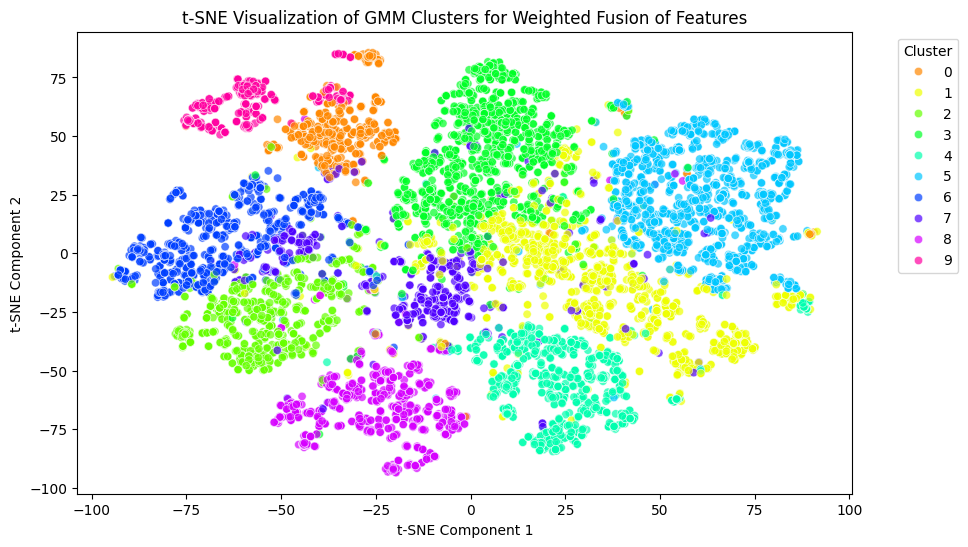

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=weighted_features_2d[:, 0],
    y=weighted_features_2d[:, 1],
    hue=fused_cluster_labels_gmm_weighted,
    palette=sns.color_palette("hsv", num_clusters),
    alpha=0.7
)
plt.title("t-SNE Visualization of GMM Clusters for Weighted Fusion of Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()